# Exploring the STEAD Dataset

This notebook demonstrates loading and visualizing seismic waveforms from the STEAD (STanford EArthquake Dataset).

In [1]:
%load_ext autoreload
%autoreload 2

%load_ext dotenv
%dotenv

In [5]:
import sys

# Add src to path for imports
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from data import STEADDataset, plot_waveform, plot_waveform_batch, normalize_waveform, apply_filter

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

## Load the Dataset

In [6]:
# Load earthquake dataset
earthquake_dataset = STEADDataset(
    hdf5_path='../STEAD/merge.hdf5',
    csv_path='../STEAD/merge.csv',
    trace_category='earthquake_local',
    channel='all',  # Load all 3 channels (E, N, Z)
)

print(f"Earthquake dataset statistics:")
for key, value in earthquake_dataset.get_stats().items():
    print(f"  {key}: {value}")

Earthquake dataset statistics:
  total_samples: 1030231
  earthquakes: 1030231
  noise: 0
  magnitude_range: (-0.5, 7.9)
  distance_range_km: (0.0, 346.27)


## Load a Random Earthquake Sample

In [8]:
# Pick a random index
random_idx = np.random.randint(0, len(earthquake_dataset))
print(f"Loading sample {random_idx} of {len(earthquake_dataset)}")

# Get the sample
sample = earthquake_dataset[random_idx]

print(f"\nSample info:")
print(f"  Trace name: {sample['trace_name']}")
print(f"  Category: {sample['trace_category']}")
print(f"  Magnitude: {sample['source_magnitude']}")
print(f"  Distance: {sample['source_distance_km']} km")
print(f"  Depth: {sample['source_depth_km']} km")
print(f"  P arrival: {sample['p_arrival_sample']} samples")
print(f"  S arrival: {sample['s_arrival_sample']} samples")
print(f"  Waveform shape: {sample['waveform'].shape}")

Loading sample 461929 of 1030231

Sample info:
  Trace name: EMB.NN_20151030071942_EV
  Category: earthquake_local
  Magnitude: 0.0
  Distance: 27.81 km
  Depth: 8.9 km
  P arrival: 900 samples
  S arrival: 1276 samples
  Waveform shape: torch.Size([3, 6000])


## Visualize the Waveform

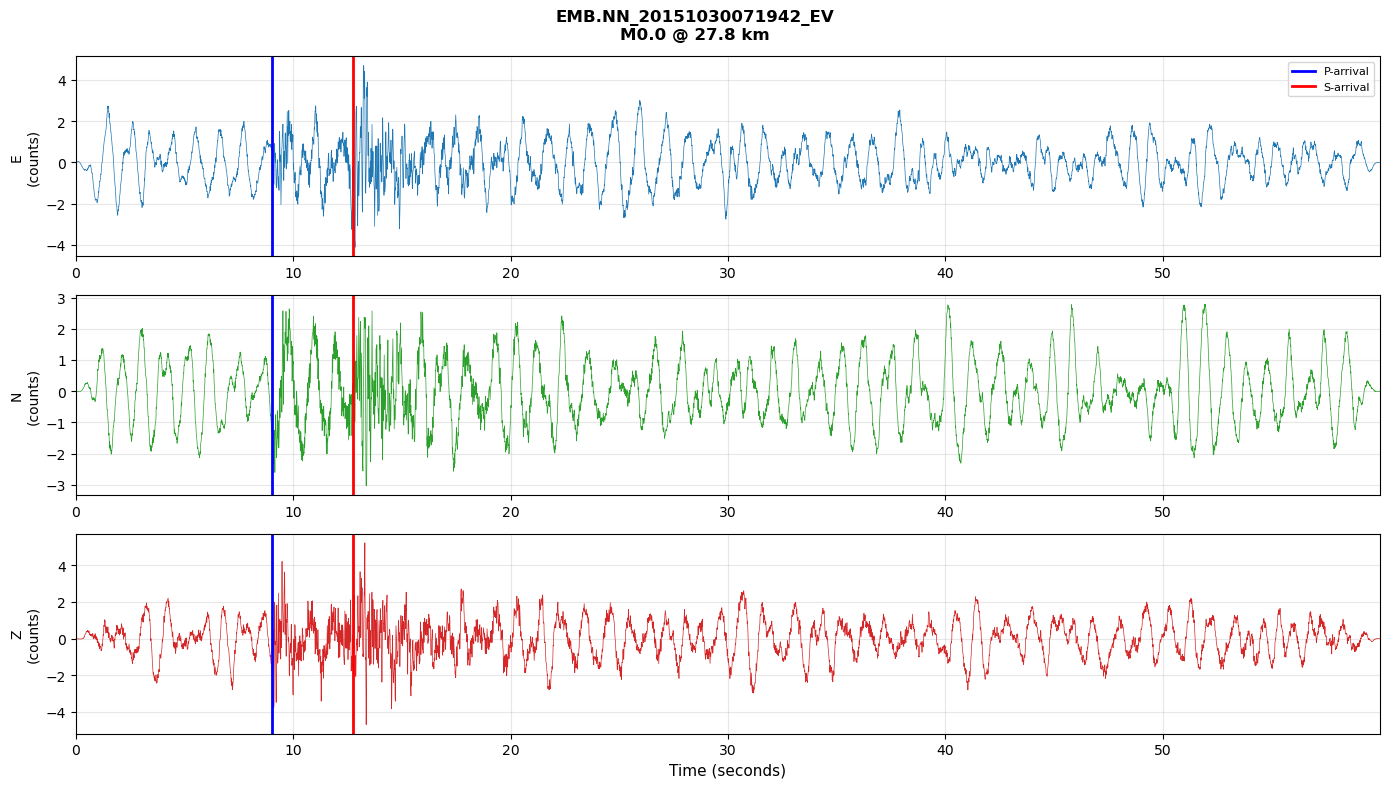

In [9]:
# Plot using the standalone visualization function
fig = plot_waveform(
    sample,
    show_arrivals=True,
    show_spectrogram=False,
    figsize=(14, 8),
    channels='all'
)
plt.show()

## View with Spectrogram

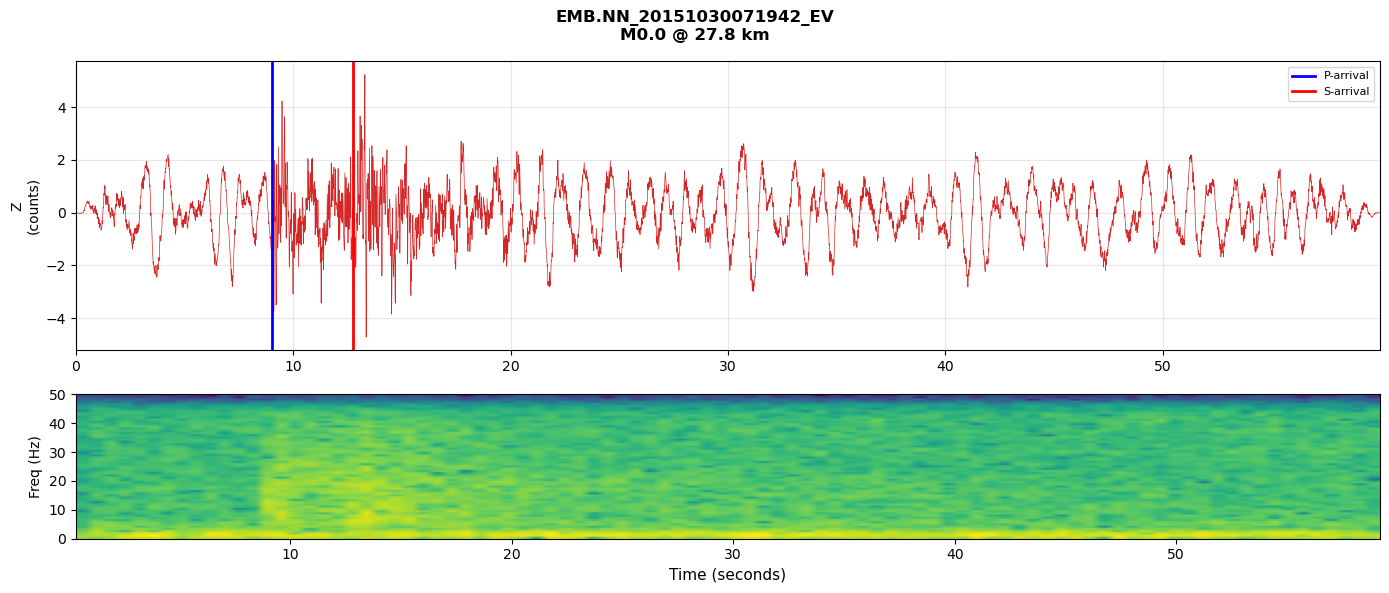

In [10]:
# Plot with spectrogram (Z channel only for clarity)
fig = plot_waveform(
    sample,
    show_arrivals=True,
    show_spectrogram=True,
    figsize=(14, 6),
    channels='Z'
)
plt.show()

## Convert to ObsPy Stream

In [11]:
# Convert to ObsPy for advanced seismological processing
stream = earthquake_dataset.to_obspy_stream(random_idx)
print(stream)
print(f"\nTrace stats:")
print(stream[0].stats)

3 Trace(s) in Stream:
NN.EMB..HHE | 2015-10-30T07:19:43.059830Z - 2015-10-30T07:20:43.049830Z | 100.0 Hz, 6000 samples
NN.EMB..HHN | 2015-10-30T07:19:43.059830Z - 2015-10-30T07:20:43.049830Z | 100.0 Hz, 6000 samples
NN.EMB..HHZ | 2015-10-30T07:19:43.059830Z - 2015-10-30T07:20:43.049830Z | 100.0 Hz, 6000 samples

Trace stats:
         network: NN
         station: EMB
        location: 
         channel: HHE
       starttime: 2015-10-30T07:19:43.059830Z
         endtime: 2015-10-30T07:20:43.049830Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 6000
           calib: 1.0


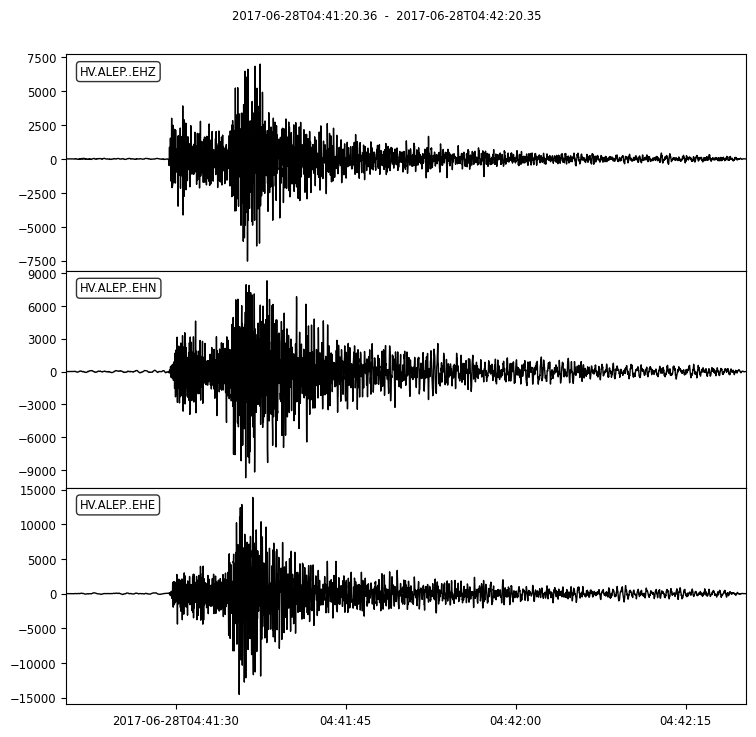

In [41]:
# Use ObsPy's built-in plotting
stream.plot(equal_scale=False);

## Compare Multiple Random Samples

Plotting samples: [385493, 404885, 667112, 118364, 541867, 565409]


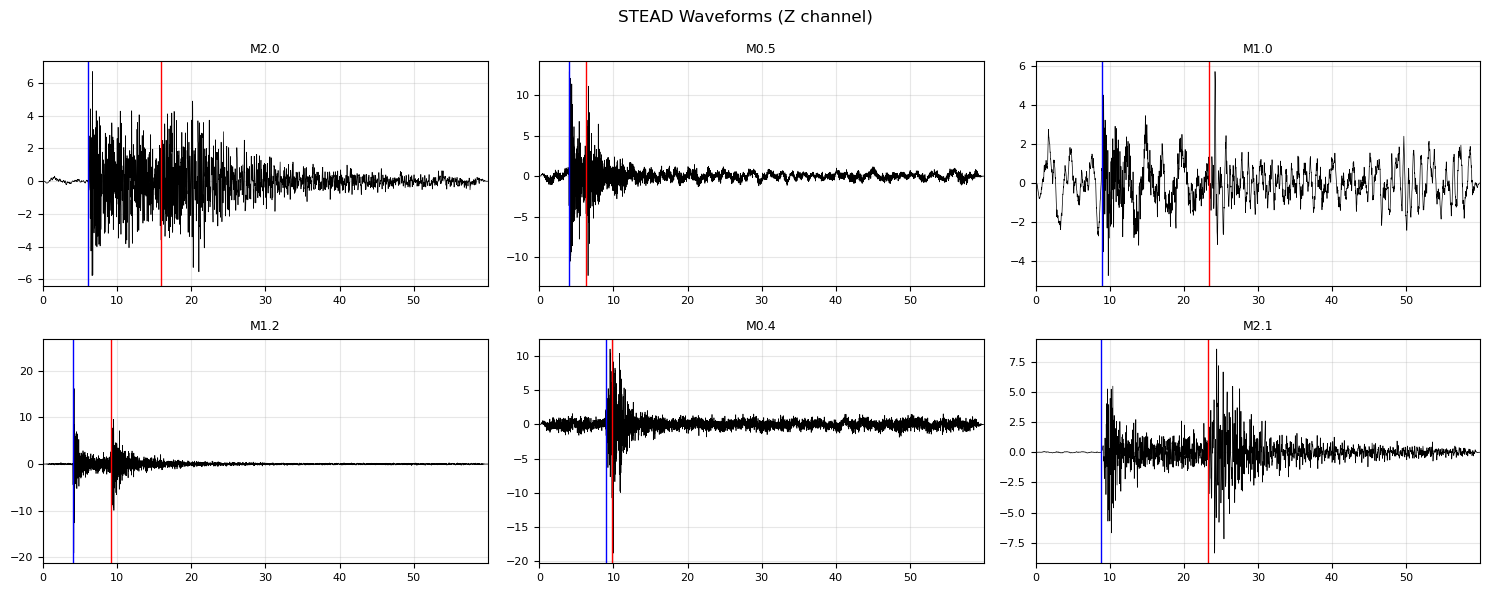

In [12]:
# Plot a batch of random samples
random_indices = np.random.choice(len(earthquake_dataset), size=6, replace=False)
print(f"Plotting samples: {random_indices.tolist()}")

# Get the samples
samples = [earthquake_dataset[i] for i in random_indices]

fig = plot_waveform_batch(
    samples,
    ncols=3,
    figsize_per_plot=(5, 3),
    channel='Z',
    show_arrivals=True
)
plt.show()

## Load Noise Samples for Comparison

In [13]:
# Load noise dataset
noise_dataset = STEADDataset(
    hdf5_path='../STEAD/merge.hdf5',
    csv_path='../STEAD/merge.csv',
    trace_category='noise',
    max_samples=10000,  # Limit for faster loading
)

print(f"Noise samples: {len(noise_dataset)}")

Noise samples: 10000


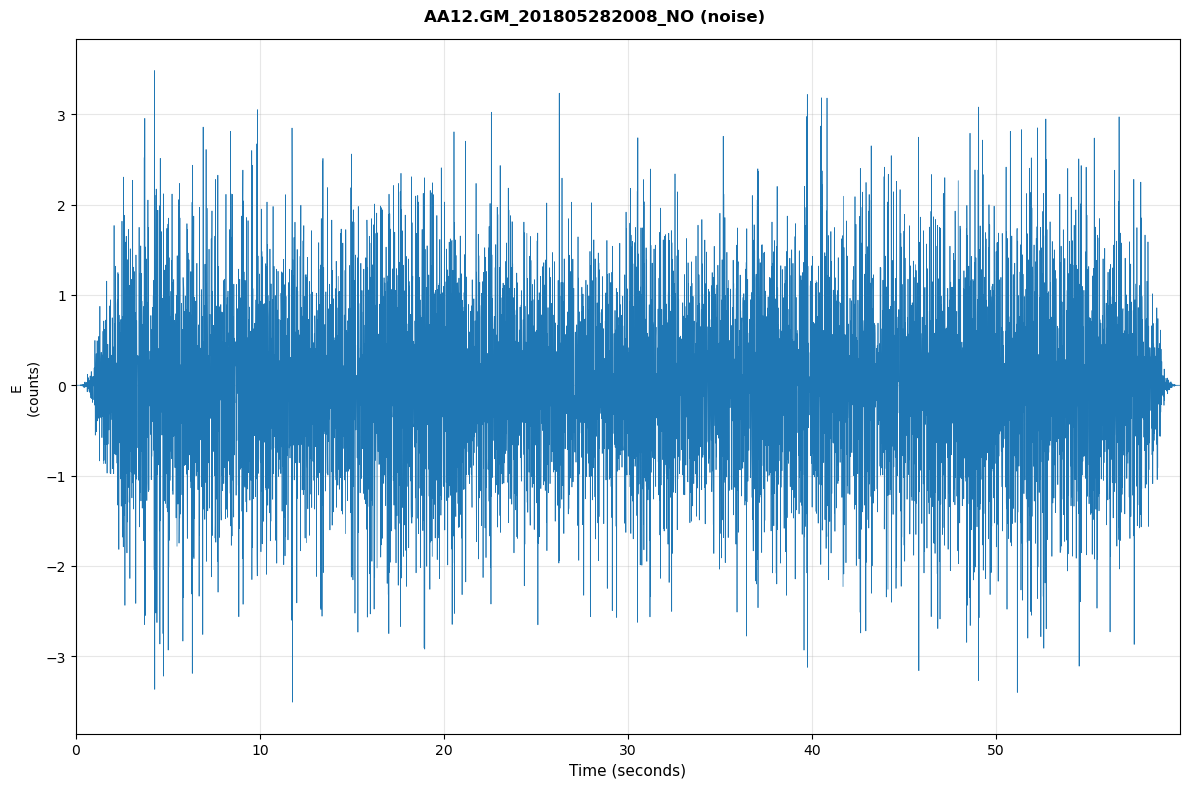

In [14]:
# Plot a random noise sample
noise_idx = np.random.randint(0, len(noise_dataset))
noise_sample = noise_dataset[noise_idx]
fig = plot_waveform(noise_sample, show_arrivals=False, channels='Z')
plt.show()

## Filter by Magnitude

In [15]:
# Load only larger earthquakes (M >= 4)
large_eq_dataset = STEADDataset(
    hdf5_path='../STEAD/merge.hdf5',
    csv_path='../STEAD/merge.csv',
    trace_category='earthquake_local',
    min_magnitude=4.0,
    max_distance_km=50,  # Close events only
)

print(f"Large earthquake samples (M>=4, <50km): {len(large_eq_dataset)}")
print(large_eq_dataset.get_stats())

Large earthquake samples (M>=4, <50km): 2119
{'total_samples': 2119, 'earthquakes': 2119, 'noise': 0, 'magnitude_range': (4.0, 6.8), 'distance_range_km': (0.89, 50.0)}


## Normalization and Filtering Comparison

Let's visualize how different normalization and filtering options affect the waveforms.

In [ ]:
# Create a raw dataset (no normalization, no filtering) for comparisons
raw_dataset = STEADDataset(
    hdf5_path='../STEAD/merge.hdf5',
    csv_path='../STEAD/merge.csv',
    trace_category='earthquake_local',
    subtract_mean=False, norm_by_std=False,  # No normalization
)


Using sample index: 883078


In [20]:
comparison_idx = np.random.randint(0, len(raw_dataset))
raw_sample = raw_dataset[comparison_idx]
raw_waveform = raw_sample['waveform'].numpy().flatten()
print(f"Using sample index: {comparison_idx}")
print(f"\nSample info:")
print(f"  Trace name: {raw_sample['trace_name']}")
print(f"  Category: {raw_sample['trace_category']}")
print(f"  Magnitude: {raw_sample['source_magnitude']}")
print(f"  Distance: {raw_sample['source_distance_km']} km")
print(f"  Depth: {raw_sample['source_depth_km']} km")
print(f"  P arrival: {raw_sample['p_arrival_sample']} samples")
print(f"  S arrival: {raw_sample['s_arrival_sample']} samples")
print(f"  Waveform shape: {raw_sample['waveform'].shape}")

Using sample index: 249138

Sample info:
  Trace name: B916.PB_20130117102819_EV
  Category: earthquake_local
  Magnitude: 1.94
  Distance: 35.6 km
  Depth: -1.13 km
  P arrival: 900 samples
  S arrival: 1368 samples
  Waveform shape: torch.Size([1, 6000])


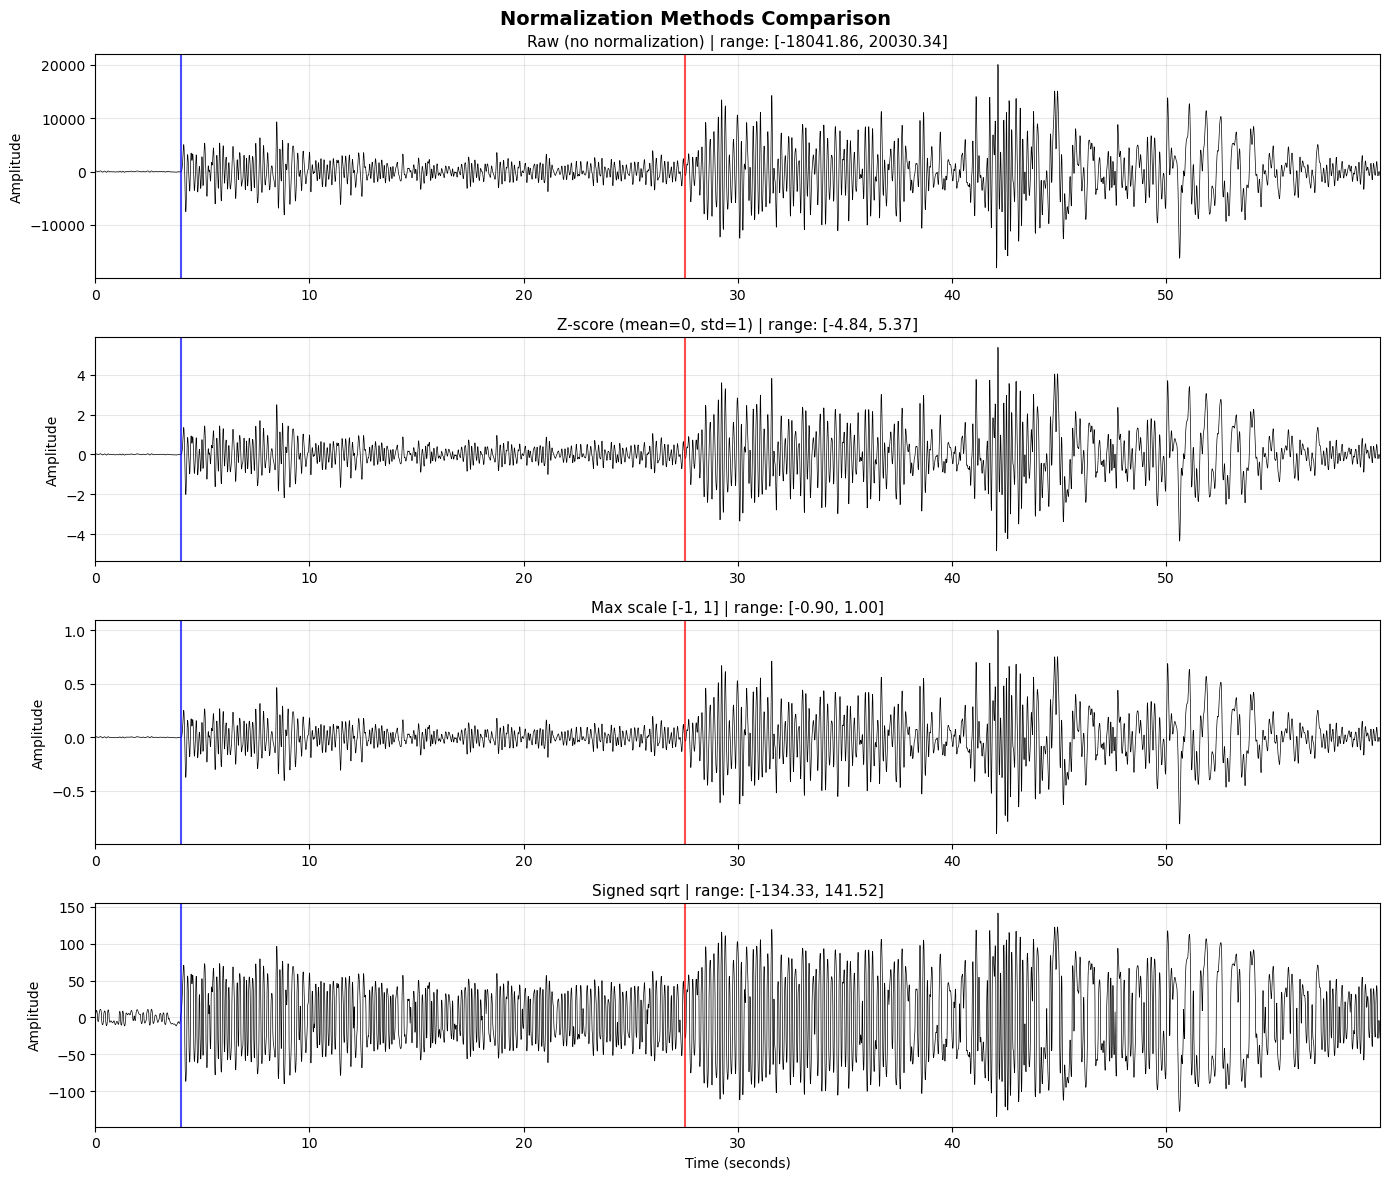

In [17]:
# Compare different normalization methods using normalize_waveform function
normalization_configs = {
    'Raw (no normalization)': dict(subtract_mean=False, norm_by_std=False),
    'Z-score (mean=0, std=1)': dict(subtract_mean=True, norm_by_std=True),
    'Max scale [-1, 1]': dict(subtract_mean=True, norm_by_std=False, norm_by_max=True),
    'Signed sqrt': dict(subtract_mean=True, norm_by_std=False, signed_sqrt=True, signed_sqrt_factor=0.5),
}

time = np.arange(len(raw_waveform)) / 100
fig, axes = plt.subplots(len(normalization_configs), 1, figsize=(14, 3*len(normalization_configs)))

for ax, (name, norm_kwargs) in zip(axes, normalization_configs.items()):
    # Apply normalization function directly to raw waveform
    waveform = normalize_waveform(raw_waveform.copy(), **norm_kwargs)
    
    ax.plot(time, waveform, 'k', linewidth=0.5)
    ax.set_title(f"{name} | range: [{waveform.min():.2f}, {waveform.max():.2f}]", fontsize=11)
    ax.set_xlim(0, time[-1])
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    
    # Mark P and S arrivals
    if raw_sample['p_arrival_sample']:
        ax.axvline(raw_sample['p_arrival_sample'] / 100, color='blue', linewidth=1.5, alpha=0.7)
    if raw_sample['s_arrival_sample']:
        ax.axvline(raw_sample['s_arrival_sample'] / 100, color='red', linewidth=1.5, alpha=0.7)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Normalization Methods Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Small vs Large Earthquake Comparison

Compare how normalization affects small (M < 1.0) vs large (M > 6.0) earthquakes.

In [24]:
# Find a small and a large earthquake
small_eq_mask = raw_dataset.metadata['source_magnitude'] < 1.0
large_eq_mask = raw_dataset.metadata['source_magnitude'] > 6.0

print(f"Small earthquakes (M < 1.0): {small_eq_mask.sum()}")
print(f"Large earthquakes (M > 6.0): {large_eq_mask.sum()}")

# Get indices
small_eq_indices = raw_dataset.metadata[small_eq_mask].index.tolist()
large_eq_indices = raw_dataset.metadata[large_eq_mask].index.tolist()

if small_eq_indices and large_eq_indices:
    small_idx = np.random.choice(small_eq_indices)
    large_idx = np.random.choice(large_eq_indices)
    
    small_sample = raw_dataset[small_idx]
    large_sample = raw_dataset[large_idx]
    
    small_wf = small_sample['waveform'].numpy().flatten()
    large_wf = large_sample['waveform'].numpy().flatten()
    
    print(f"\nSmall EQ: M{small_sample['source_magnitude']:.1f}, {small_sample['source_distance_km']:.0f} km")
    print(f"Large EQ: M{large_sample['source_magnitude']:.1f}, {large_sample['source_distance_km']:.0f} km")
else:
    print("Not enough earthquakes in the filtered range. Try with the full dataset.")

Small earthquakes (M < 1.0): 347431
Large earthquakes (M > 6.0): 123

Small EQ: M0.3, 16 km
Large EQ: M6.3, 285 km


In [33]:
print(f"max: small: {np.abs(small_wf).max()},\t large:{np.abs(large_wf).max()}")
print(f"max^0.5: small: {np.abs(small_wf).max()**0.5},\t large:{np.abs(large_wf).max()**0.5}")

max: small: 275.25640869140625,	 large:1870672.75
max^0.5: small: 16.590853163457457,	 large:1367.7253927598185


In [34]:
def plot_arrivals(sample, ax):
    if large_sample['p_arrival_sample']:
        ax.axvline(sample['p_arrival_sample'] / 100, color='blue', lw=1.5, alpha=0.7)
    if large_sample['s_arrival_sample']:
        ax.axvline(sample['s_arrival_sample'] / 100, color='red', lw=1.5, alpha=0.7)

max waveform: small: 275.25640869140625,	 large:1870672.75
max normalized: small: 275.25640869140625,	 large:1870672.75
max waveform: small: 275.25640869140625,	 large:1870672.75
max normalized: small: 32.634246826171875,	 large:5.865153789520264
max waveform: small: 275.25640869140625,	 large:1870672.75
max normalized: small: 1.0,	 large:1.0
max waveform: small: 275.25640869140625,	 large:1870672.75
max normalized: small: 4.073187828063965,	 large:36.98469543457031


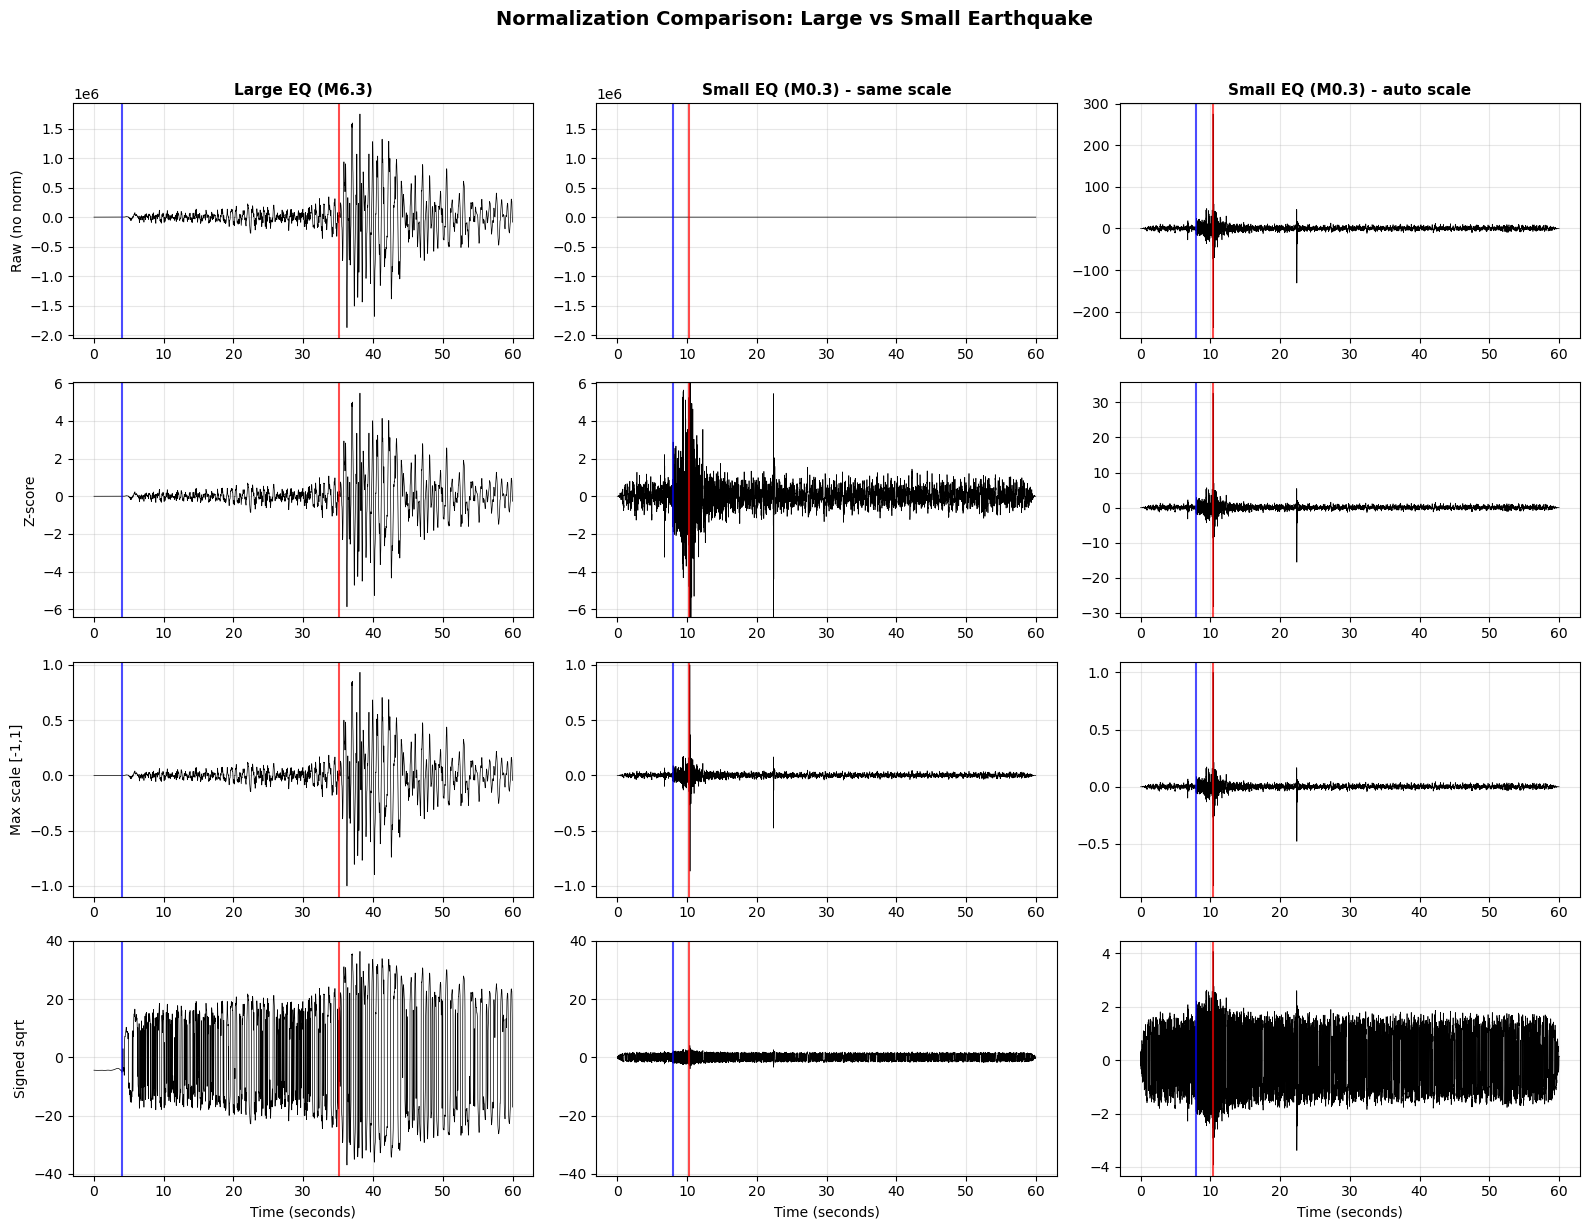

In [38]:
# Compare all normalizations: 3 columns per row
# Left: Large EQ | Middle: Small EQ (same scale) | Right: Small EQ (auto scale)

normalization_configs = {
    'Raw (no norm)': dict(subtract_mean=False, norm_by_std=False),
    'Z-score': dict(subtract_mean=True, norm_by_std=True),
    'Max scale [-1,1]': dict(subtract_mean=True, norm_by_max=True),
    'Signed sqrt': dict(subtract_mean=True, signed_sqrt=True, signed_sqrt_factor=0.25),
}

time = np.arange(6000) / 100
n_rows = len(normalization_configs)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 3 * n_rows))

for row, (name, norm_kwargs) in enumerate(normalization_configs.items()):
    large_norm = normalize_waveform(large_wf.copy(), **norm_kwargs)
    small_norm = normalize_waveform(small_wf.copy(), **norm_kwargs)


    print(f"max waveform: small: {np.abs(small_wf).max()},\t large:{np.abs(large_wf).max()}")
    print(f"max normalized: small: {np.abs(small_norm).max()},\t large:{np.abs(large_norm).max()}")
    
    # Column 0: Large earthquake
    axes[row, 0].plot(time, large_norm, 'k', linewidth=0.5)
    axes[row, 0].set_ylabel(name, fontsize=10)
    axes[row, 0].grid(True, alpha=0.3)
    plot_arrivals(large_sample, axes[row, 0])
    large_ylim = axes[row, 0].get_ylim()
    
    # Column 1: Small earthquake - SAME scale as large
    axes[row, 1].plot(time, small_norm, 'k', linewidth=0.5)
    axes[row, 1].set_ylim(large_ylim)
    axes[row, 1].grid(True, alpha=0.3)
    plot_arrivals(small_sample, axes[row, 1])
    
    # Column 2: Small earthquake - AUTO scale
    axes[row, 2].plot(time, small_norm, 'k', linewidth=0.5)
    axes[row, 2].grid(True, alpha=0.3)
    plot_arrivals(small_sample, axes[row, 2])
# Column headers
axes[0, 0].set_title(f"Large EQ (M{large_sample['source_magnitude']:.1f})", fontsize=11, fontweight='bold')
axes[0, 1].set_title(f"Small EQ (M{small_sample['source_magnitude']:.1f}) - same scale", fontsize=11, fontweight='bold')
axes[0, 2].set_title(f"Small EQ (M{small_sample['source_magnitude']:.1f}) - auto scale", fontsize=11, fontweight='bold')

# X labels on bottom row
for col in range(3):
    axes[-1, col].set_xlabel('Time (seconds)')

fig.suptitle('Normalization Comparison: Large vs Small Earthquake', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Filter Comparison

Compare high-pass, low-pass, and bandpass filters.

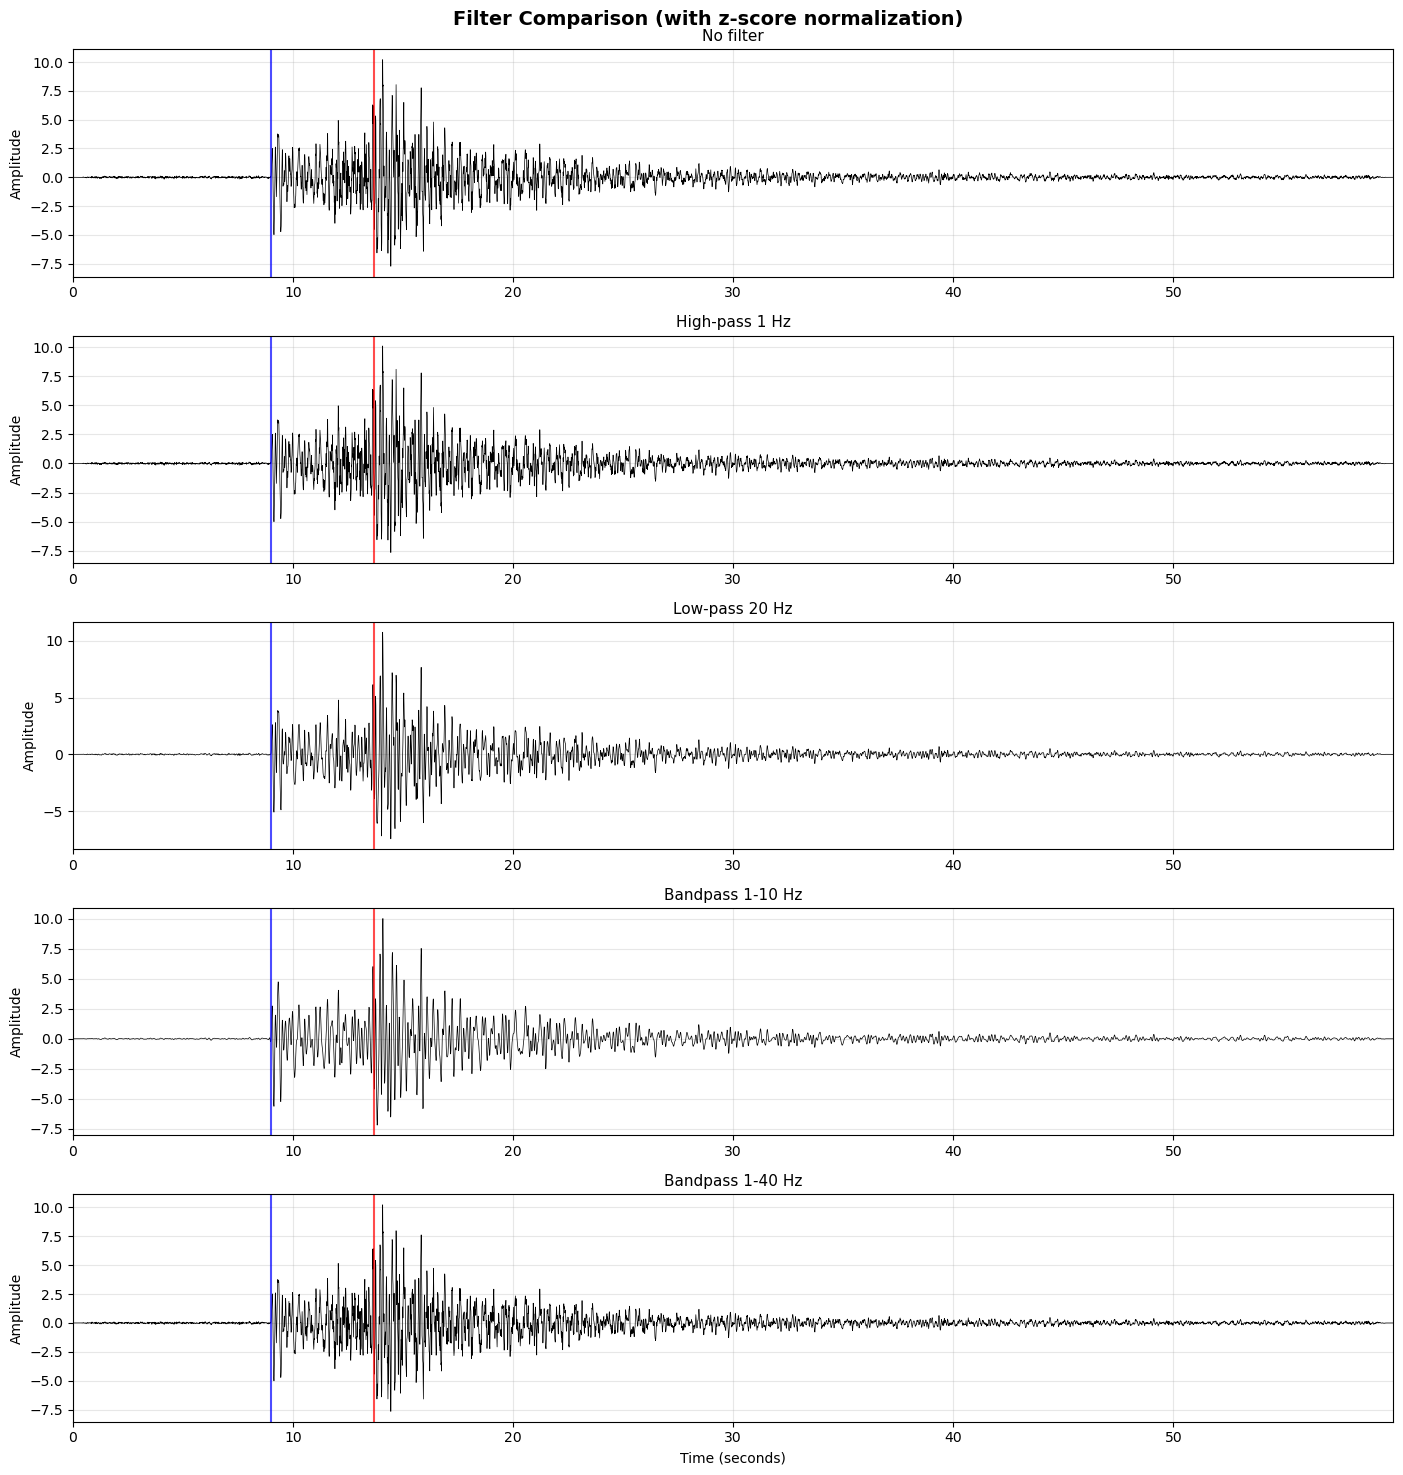

In [21]:
# Compare different filter settings using apply_filter function
SAMPLE_RATE = 100  # Hz

filter_configs = {
    'No filter': dict(),
    'High-pass 1 Hz': dict(highpass_freq=1.0),
    'Low-pass 20 Hz': dict(lowpass_freq=20.0),
    'Bandpass 1-10 Hz': dict(highpass_freq=1.0, lowpass_freq=10.0),
    'Bandpass 1-40 Hz': dict(highpass_freq=1.0, lowpass_freq=40.0),
}

time = np.arange(len(raw_waveform)) / SAMPLE_RATE
fig, axes = plt.subplots(len(filter_configs), 1, figsize=(14, 3*len(filter_configs)))

for ax, (name, filter_kwargs) in zip(axes, filter_configs.items()):
    # Apply filter function directly, then normalize for display
    if filter_kwargs:
        waveform = apply_filter(raw_waveform.copy(), sample_rate=SAMPLE_RATE, **filter_kwargs)
    else:
        waveform = raw_waveform.copy()
    waveform = normalize_waveform(waveform)  # z-score for consistent display
    
    ax.plot(time, waveform, 'k', linewidth=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlim(0, time[-1])
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    
    if raw_sample['p_arrival_sample']:
        ax.axvline(raw_sample['p_arrival_sample'] / SAMPLE_RATE, color='blue', linewidth=1.5, alpha=0.7)
    if raw_sample['s_arrival_sample']:
        ax.axvline(raw_sample['s_arrival_sample'] / SAMPLE_RATE, color='red', linewidth=1.5, alpha=0.7)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Filter Comparison (with z-score normalization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Spectrogram Comparison

View frequency content before and after filtering.

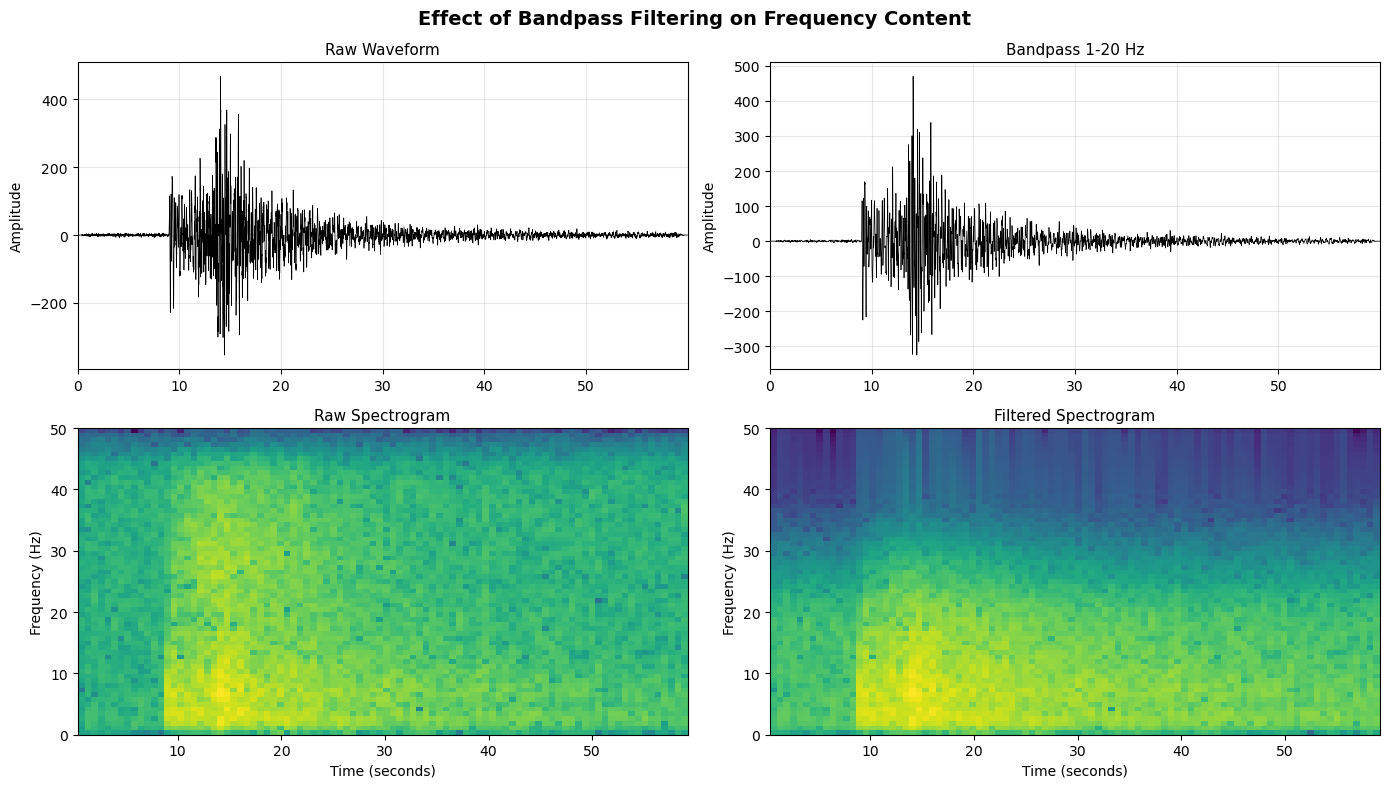

In [22]:
# Spectrogram comparison: raw vs filtered (using apply_filter directly)
filt_waveform = apply_filter(raw_waveform.copy(), highpass_freq=1.0, lowpass_freq=20.0, sample_rate=SAMPLE_RATE)
time = np.arange(len(raw_waveform)) / SAMPLE_RATE

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw waveform
axes[0, 0].plot(time, raw_waveform, 'k', linewidth=0.5)
axes[0, 0].set_title('Raw Waveform', fontsize=11)
axes[0, 0].set_xlim(0, time[-1])
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

# Raw spectrogram
axes[1, 0].specgram(raw_waveform, Fs=SAMPLE_RATE, cmap='viridis', NFFT=128, noverlap=64)
axes[1, 0].set_title('Raw Spectrogram', fontsize=11)
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].set_xlabel('Time (seconds)')
axes[1, 0].set_ylim(0, 50)

# Filtered waveform
axes[0, 1].plot(time, filt_waveform, 'k', linewidth=0.5)
axes[0, 1].set_title('Bandpass 1-20 Hz', fontsize=11)
axes[0, 1].set_xlim(0, time[-1])
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True, alpha=0.3)

# Filtered spectrogram
axes[1, 1].specgram(filt_waveform, Fs=SAMPLE_RATE, cmap='viridis', NFFT=128, noverlap=64)
axes[1, 1].set_title('Filtered Spectrogram', fontsize=11)
axes[1, 1].set_ylabel('Frequency (Hz)')
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_ylim(0, 50)

fig.suptitle('Effect of Bandpass Filtering on Frequency Content', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Amplitude Distribution Comparison

Compare how different normalizations affect the amplitude distribution.

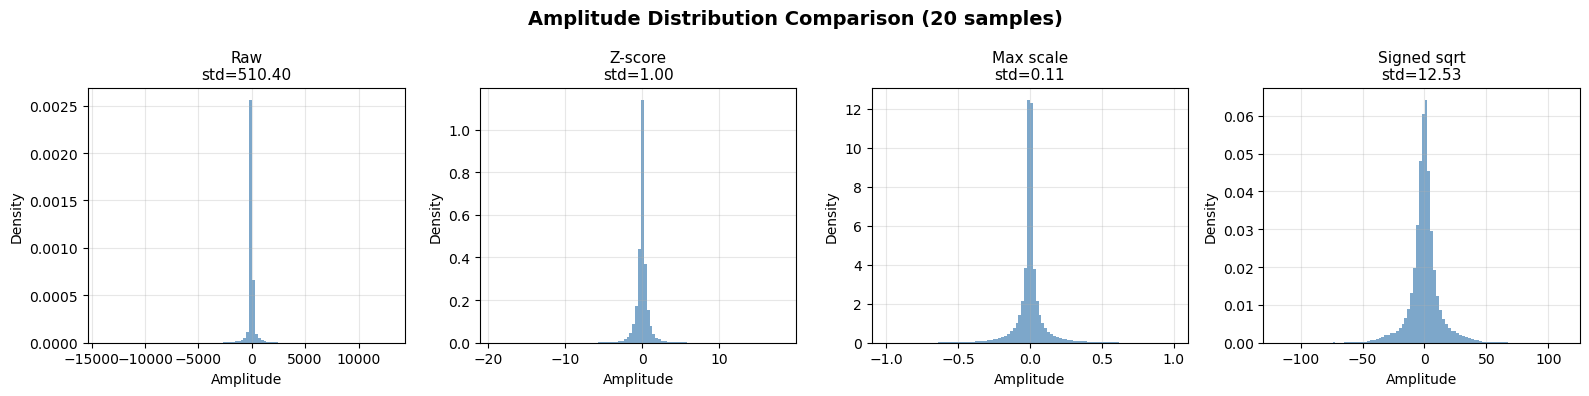

In [23]:
# Compare amplitude distributions across multiple samples
n_samples = 20
random_indices = np.random.choice(len(earthquake_dataset), size=n_samples, replace=False)

norm_configs = {
    'Raw': dict(subtract_mean=False, norm_by_std=False),
    'Z-score': dict(subtract_mean=True, norm_by_std=True),
    'Max scale': dict(subtract_mean=True, norm_by_std=False, norm_by_max=True),
    'Signed sqrt': dict(subtract_mean=True, norm_by_std=False, signed_sqrt=True),
}

fig, axes = plt.subplots(1, len(norm_configs), figsize=(16, 4))

for ax, (name, norm_kwargs) in zip(axes, norm_configs.items()):
    ds = STEADDataset(
        hdf5_path='../STEAD/merge.hdf5',
        csv_path='../STEAD/merge.csv',
        trace_category='earthquake_local',
        max_samples=max(random_indices) + 1,
        **norm_kwargs
    )
    
    # Collect all amplitudes
    all_amplitudes = []
    for idx in random_indices:
        wf = ds[idx]['waveform'].numpy().flatten()
        all_amplitudes.extend(wf)
    
    all_amplitudes = np.array(all_amplitudes)
    
    # Plot histogram
    ax.hist(all_amplitudes, bins=100, density=True, alpha=0.7, color='steelblue')
    ax.set_title(f'{name}\nstd={all_amplitudes.std():.2f}', fontsize=11)
    ax.set_xlabel('Amplitude')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Amplitude Distribution Comparison ({n_samples} samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Earthquake vs Noise Comparison

Compare earthquake and noise waveforms with the same preprocessing.

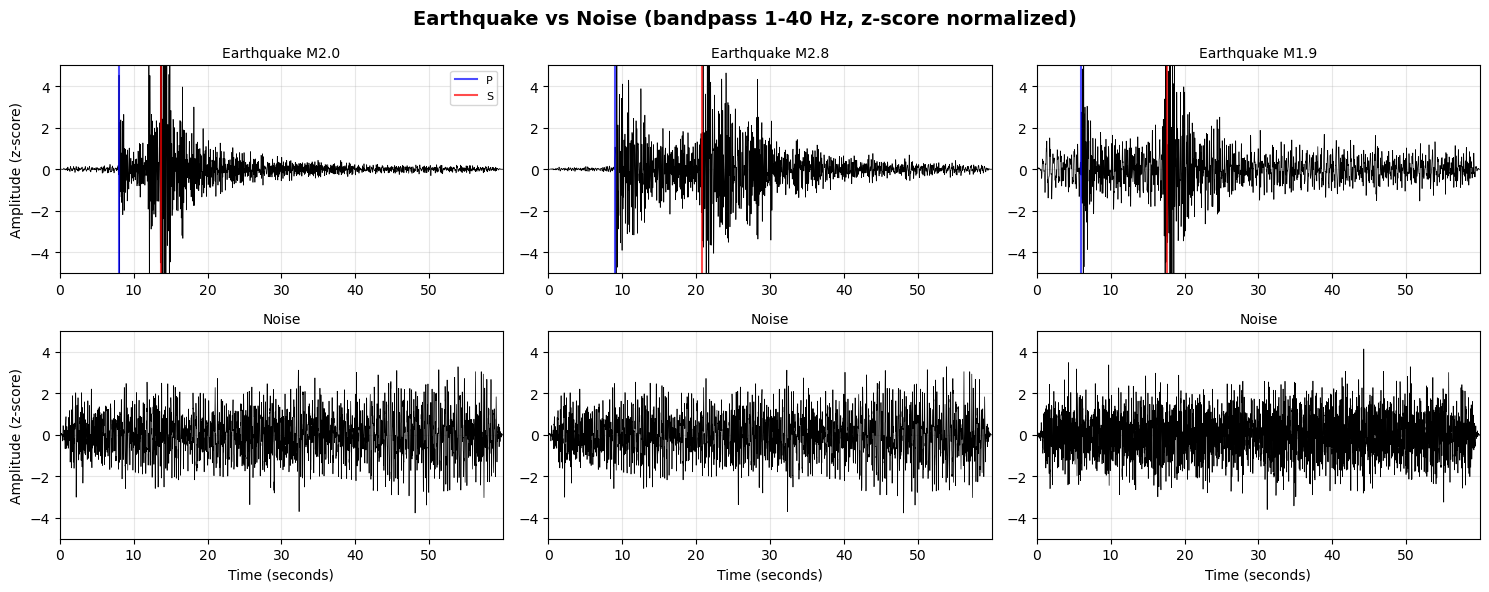

In [32]:
# Load earthquake and noise with same preprocessing
common_kwargs = dict(
    hdf5_path='../STEAD/merge.hdf5',
    csv_path='../STEAD/merge.csv',
    highpass_freq=1.0,
    lowpass_freq=40.0,
    subtract_mean=True,
    norm_by_std=True,
)

eq_ds = STEADDataset(trace_category='earthquake_local', max_samples=100, **common_kwargs)
noise_ds = STEADDataset(trace_category='noise', max_samples=100, **common_kwargs)

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

# Plot 3 earthquake samples
for i, ax in enumerate(axes[0]):
    idx = np.random.randint(0, len(eq_ds))
    sample = eq_ds[idx]
    wf = sample['waveform'].numpy().flatten()
    time = np.arange(len(wf)) / 100
    
    ax.plot(time, wf, 'k', linewidth=0.5)
    ax.set_title(f"Earthquake M{sample['source_magnitude']:.1f}", fontsize=10)
    ax.set_xlim(0, time[-1])
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)
    
    if sample['p_arrival_sample']:
        ax.axvline(sample['p_arrival_sample'] / 100, color='blue', linewidth=1.5, alpha=0.7, label='P')
    if sample['s_arrival_sample']:
        ax.axvline(sample['s_arrival_sample'] / 100, color='red', linewidth=1.5, alpha=0.7, label='S')
    
    if i == 0:
        ax.set_ylabel('Amplitude (z-score)')
        ax.legend(loc='upper right', fontsize=8)

# Plot 3 noise samples
for i, ax in enumerate(axes[1]):
    idx = np.random.randint(0, len(noise_ds))
    sample = noise_ds[idx]
    wf = sample['waveform'].numpy().flatten()
    time = np.arange(len(wf)) / 100
    
    ax.plot(time, wf, 'k', linewidth=0.5)
    ax.set_title('Noise', fontsize=10)
    ax.set_xlim(0, time[-1])
    ax.set_ylim(-5, 5)
    ax.set_xlabel('Time (seconds)')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.set_ylabel('Amplitude (z-score)')

fig.suptitle('Earthquake vs Noise (bandpass 1-40 Hz, z-score normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()